In [1]:
pip install pandas numpy matplotlib seaborn streamlit scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\vinee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

df = pd.read_csv("predictive_maintenance.csv")

print(df.head())
print(df.info())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (tota

In [5]:
print(df.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target',
       'Failure Type'],
      dtype='object')


In [3]:
print(df.isnull().sum())

df = df.drop(["UDI","Product ID"], axis=1)

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


In [6]:
failure_rate = df["Target"].mean()

print("Failure Rate:", failure_rate)

Failure Rate: 0.0339


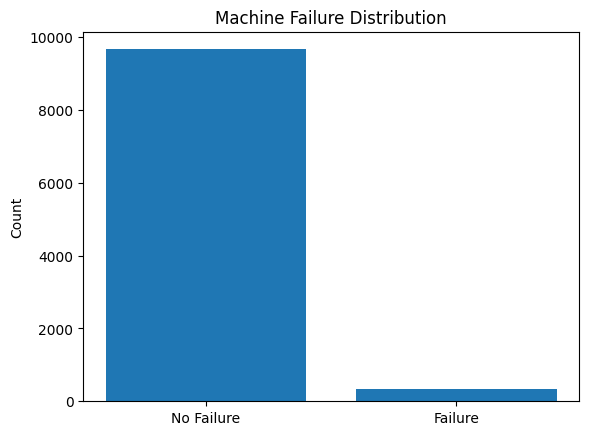

In [7]:
import matplotlib.pyplot as plt

failure_counts = df["Target"].value_counts()

plt.bar(["No Failure","Failure"], failure_counts)

plt.title("Machine Failure Distribution")

plt.ylabel("Count")

plt.show()

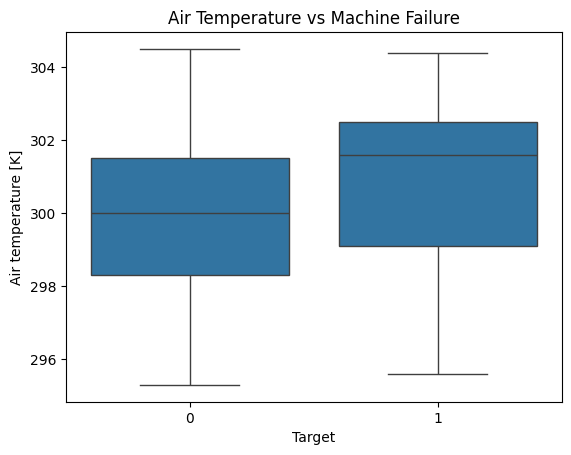

In [10]:
import seaborn as sns

sns.boxplot(x="Target", y="Air temperature [K]", data=df)

plt.title("Air Temperature vs Machine Failure")

plt.show()

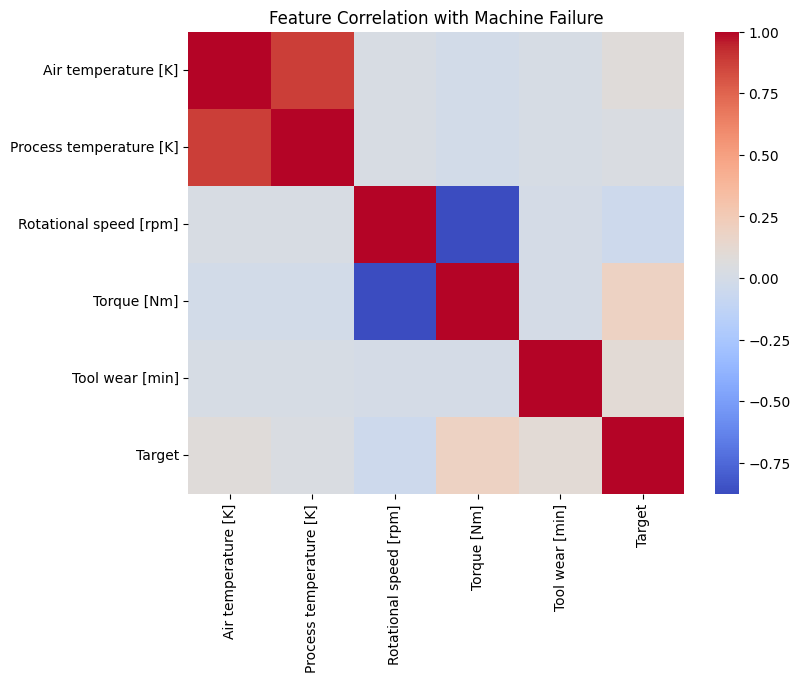

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Feature Correlation with Machine Failure")

plt.show()

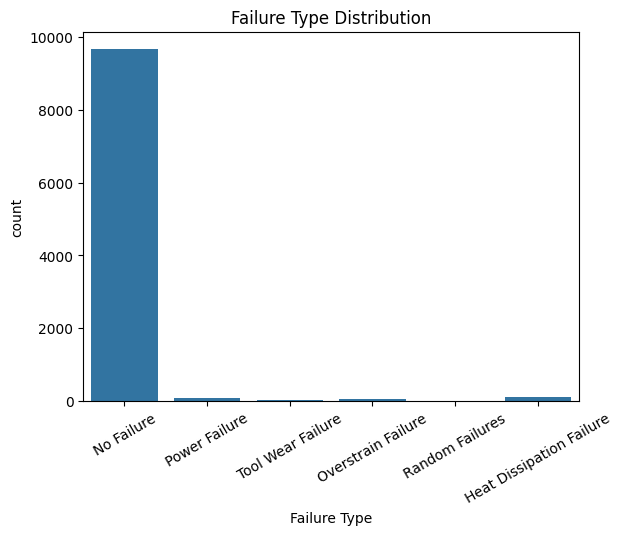

In [12]:
df["Failure Type"].value_counts()

sns.countplot(x="Failure Type", data=df)

plt.xticks(rotation=30)

plt.title("Failure Type Distribution")

plt.show()

In [13]:
df["Risk Score"] = (
    df["Air temperature [K]"]*0.3 +
    df["Process temperature [K]"]*0.3 +
    df["Tool wear [min]"]*0.4
)

In [14]:
df[["Risk Score","Target"]].head()

,Risk Score,Target
0,182.01,0
1,183.27,0
2,183.98,0
3,184.84,0
4,185.67,0


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df.drop(["Target","Failure Type"], axis=1)

X = pd.get_dummies(X)

y = df["Target"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier()

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred))

Accuracy: 0.9905
